# CNNs: getting embeddings from pre-trained CNNs

In this lab, we will use a pre-trained CNN (ResNet-18) to obtain embeddings from an image.
Specifically, we will download a [dataset of surface defects of hot-rolled steel strips by Kechen Song and Yunhui Yan](https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database).
The data contains image of steel samples exhibiting characteristics of the following classes: rolled-in scale (RS), patches (Pa), crazing (Cr), pitted surface (PS), inclusion (In) and scratches (Sc).
The database has 1,800 grayscale images.

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install torch torchvision
    !pip install tqdm
    !pip install plotly
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/11-CNNs"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

fatal: destination path 'ml4mat-26s-public' already exists and is not an empty directory.
Processing /content/ml4mat-26s-public
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ml4mat_ucla: filename=ml4mat_ucla-26.3.31-py3-none-any.whl size=11998 sha256=ff5e754674e0880606295a20151deaa7b861133f4c84406ee8f72abe3213c995
  Stored in directory: /root/.cache/pip/wheels/94/9d/4a/b4663adad4a42ccfc8463d948e4ea267b8da41d102a21f0bab
Successfully built ml4mat_ucla
  Attempting uninstall: ml4mat_ucla
    Found existing installation: ml4mat_ucla 26.3.31
    Uninstalling ml4mat_ucla-26.3.31:
      Successfully uninstalled ml4mat_ucla-26.3.31


In [2]:
%%bash

TARGET=data/neu-surface-defect-database.zip

# Create directory if not exists
mkdir -p data

# Download file if it does not exist
if [[ ! -e $TARGET ]]; then
    curl -L -o $TARGET \
      https://www.kaggle.com/api/v1/datasets/download/kaustubhdikshit/neu-surface-defect-database
fi

# Unzip dataset
unzip -q -o $TARGET -d data

In [3]:
import os
import io
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

import umap
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## Loading the images

The commands below define a transform for the data, which will be preprocessed prior to be sent to the model.
Given that we are using a pre-trained model, we have to adapt to the standards of this model.
The transformations do the following:

- Convert the grayscale image to a 3-channel image (by repeating channels)
- Resize to 224x224 (the size expected by this ResNet model.)
- Convert to a tensor and normalize with ImageNet statistics.

If we were training a CNN from scratch, this would not be necessary

In [4]:
data_dir = "data/NEU-DET/train/images"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # convert grayscale to 3 channels
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet means
                         std=[0.229, 0.224, 0.225])    # ImageNet stds
])

# Use ImageFolder which assigns labels based on the subfolder names.
dataset = ImageFolder(root=data_dir, transform=transform)
print(f"Found {len(dataset)} images in {len(dataset.classes)} classes: {dataset.classes}")

Found 1440 images in 6 classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


Now, we can create a DataLoader, which allows us to perform the operations in batches and make the most of GPU acceleration

In [5]:
batch_size = 128
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

## Loading the model

To load the model, we will define the device where the operations will be performed, then download the model weights for the pretrained ResNet18. Finally, we use the embedding layer of the ResNet-18 (prior to classification) to generate embeddings for each of the images.

In [6]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [7]:
# Use a pretrained ResNet18.
model = models.resnet18(pretrained=True)
model.eval()

# Remove the final classification layer.
# (ResNet’s children: the last layer is the fully connected layer.)
embedding_model = torch.nn.Sequential(*list(model.children())[:-1])
embedding_model.eval()
embedding_model = embedding_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Generating embeddings and unsupervised learning model

With the pre-trained model already loaded, we will obtain representations for each of the images.

In [8]:
all_embeddings = []
with torch.no_grad():
    for batch_imgs, _ in tqdm.tqdm(dataloader):
        batch_imgs = batch_imgs.to(device)
        embeddings = embedding_model(batch_imgs)
        embeddings = embeddings.view(embeddings.size(0), -1)  # shape: (batch, 512)
        all_embeddings.append(embeddings)

# Concatenate all batches.
all_embeddings = torch.cat(all_embeddings, dim=0).cpu().numpy()
print("Embeddings shape:", all_embeddings.shape)

100%|██████████| 12/12 [00:05<00:00,  2.24it/s]

Embeddings shape: (1440, 512)


In [9]:
umap_2d = umap.UMAP(n_components=2, metric="cosine")
embeddings_2d = umap_2d.fit_transform(all_embeddings)
print("UMAP embeddings shape:", embeddings_2d.shape)

UMAP embeddings shape: (1440, 2)


## Creating an interactive visualization

Finally, once we have the embeddings, we can visualize the data. Instead of making a simple data visualization, though, we will use an interactive visualization to look at the images.

All these visualization blocks had to be deleted because it was not exporting...

## Exercise

Now that you have high-quality embeddings for these images, do you think you could fit simple classifier models to predict the class of the data from the CNN embeddings?

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 'embeddings' and 'labels' are generated in the notebook
X_train, X_test, y_train, y_test = train_test_split(all_embeddings, labels, test_size=0.2, random_state=42)

# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        42
      inclusion       0.98      1.00      0.99        49
        patches       1.00      1.00      1.00        52
 pitted_surface       1.00      1.00      1.00        52
rolled-in_scale       1.00      1.00      1.00        45
      scratches       1.00      0.98      0.99        48

       accuracy                           1.00       288
      macro avg       1.00      1.00      1.00       288
   weighted avg       1.00      1.00      1.00       288



In [15]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode string labels to integers
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize and train
xgb_model = XGBClassifier(eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        42
      inclusion       0.96      1.00      0.98        49
        patches       1.00      1.00      1.00        52
 pitted_surface       1.00      0.98      0.99        52
rolled-in_scale       0.98      1.00      0.99        45
      scratches       1.00      0.96      0.98        48

       accuracy                           0.99       288
      macro avg       0.99      0.99      0.99       288
   weighted avg       0.99      0.99      0.99       288



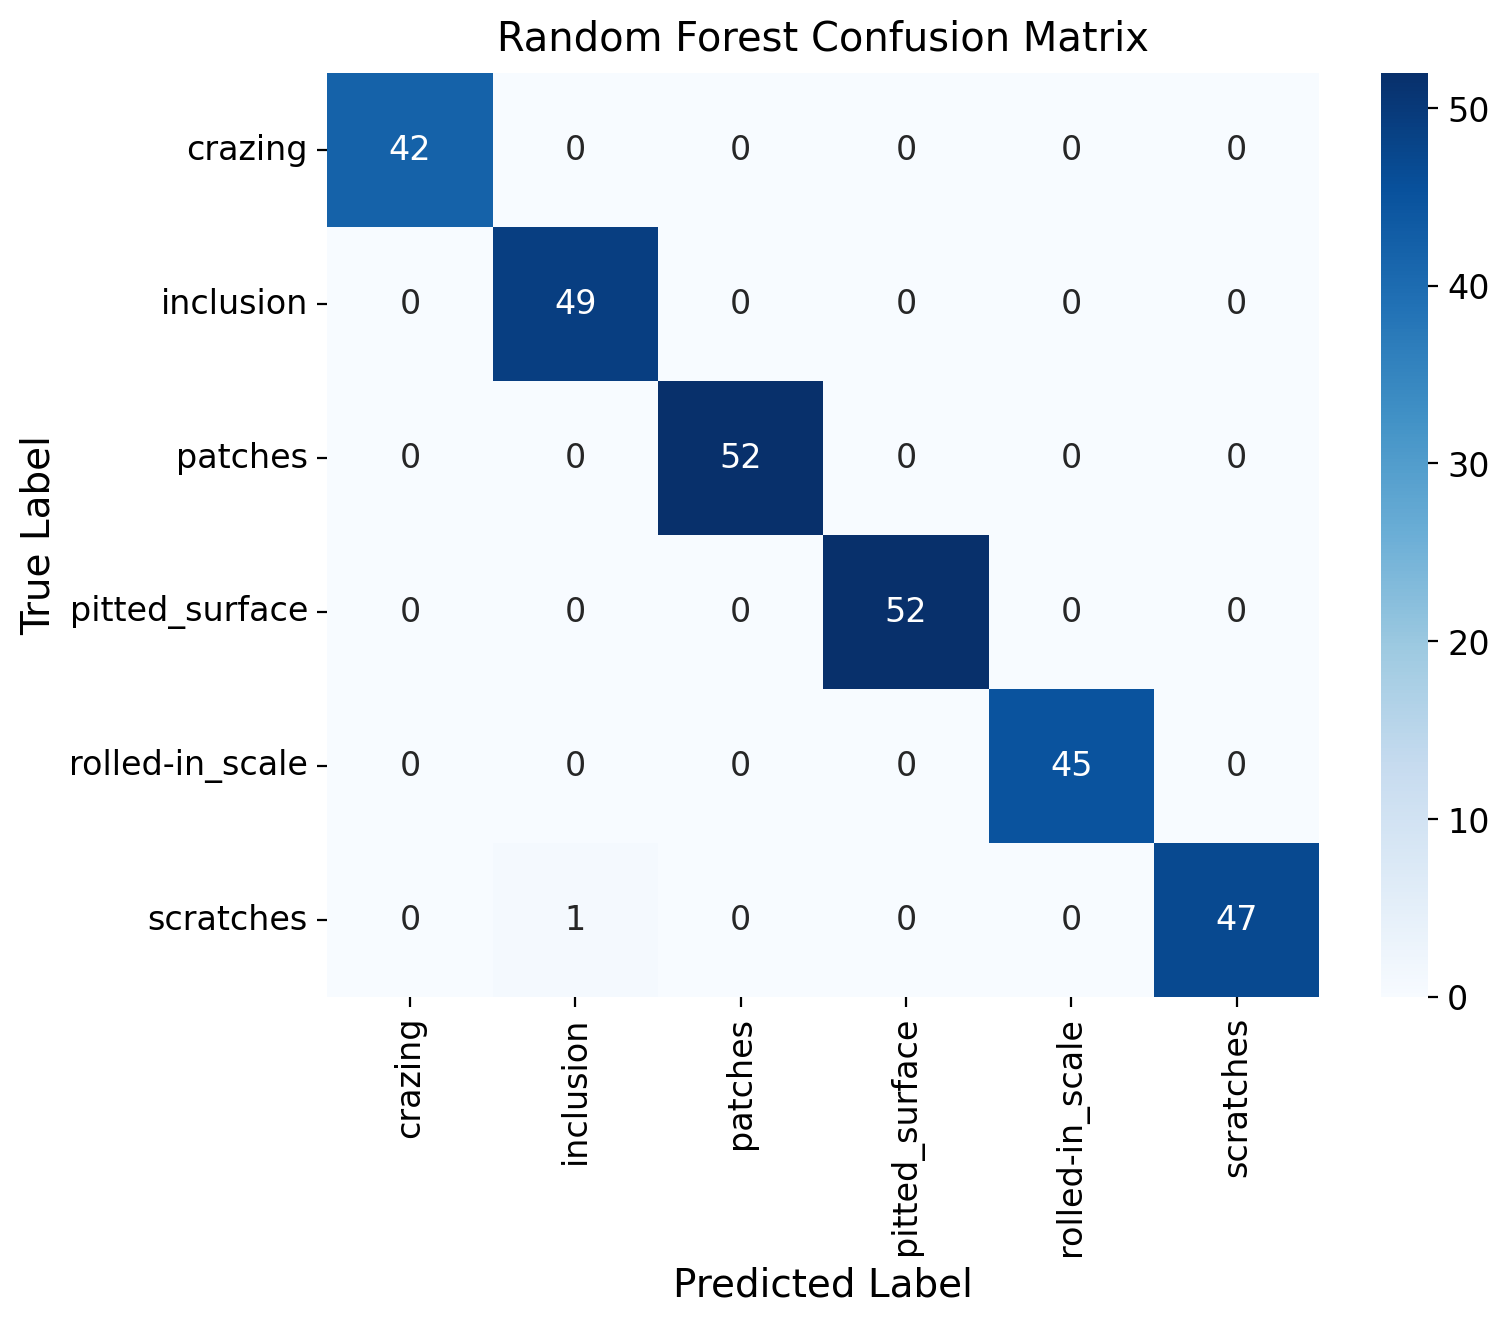

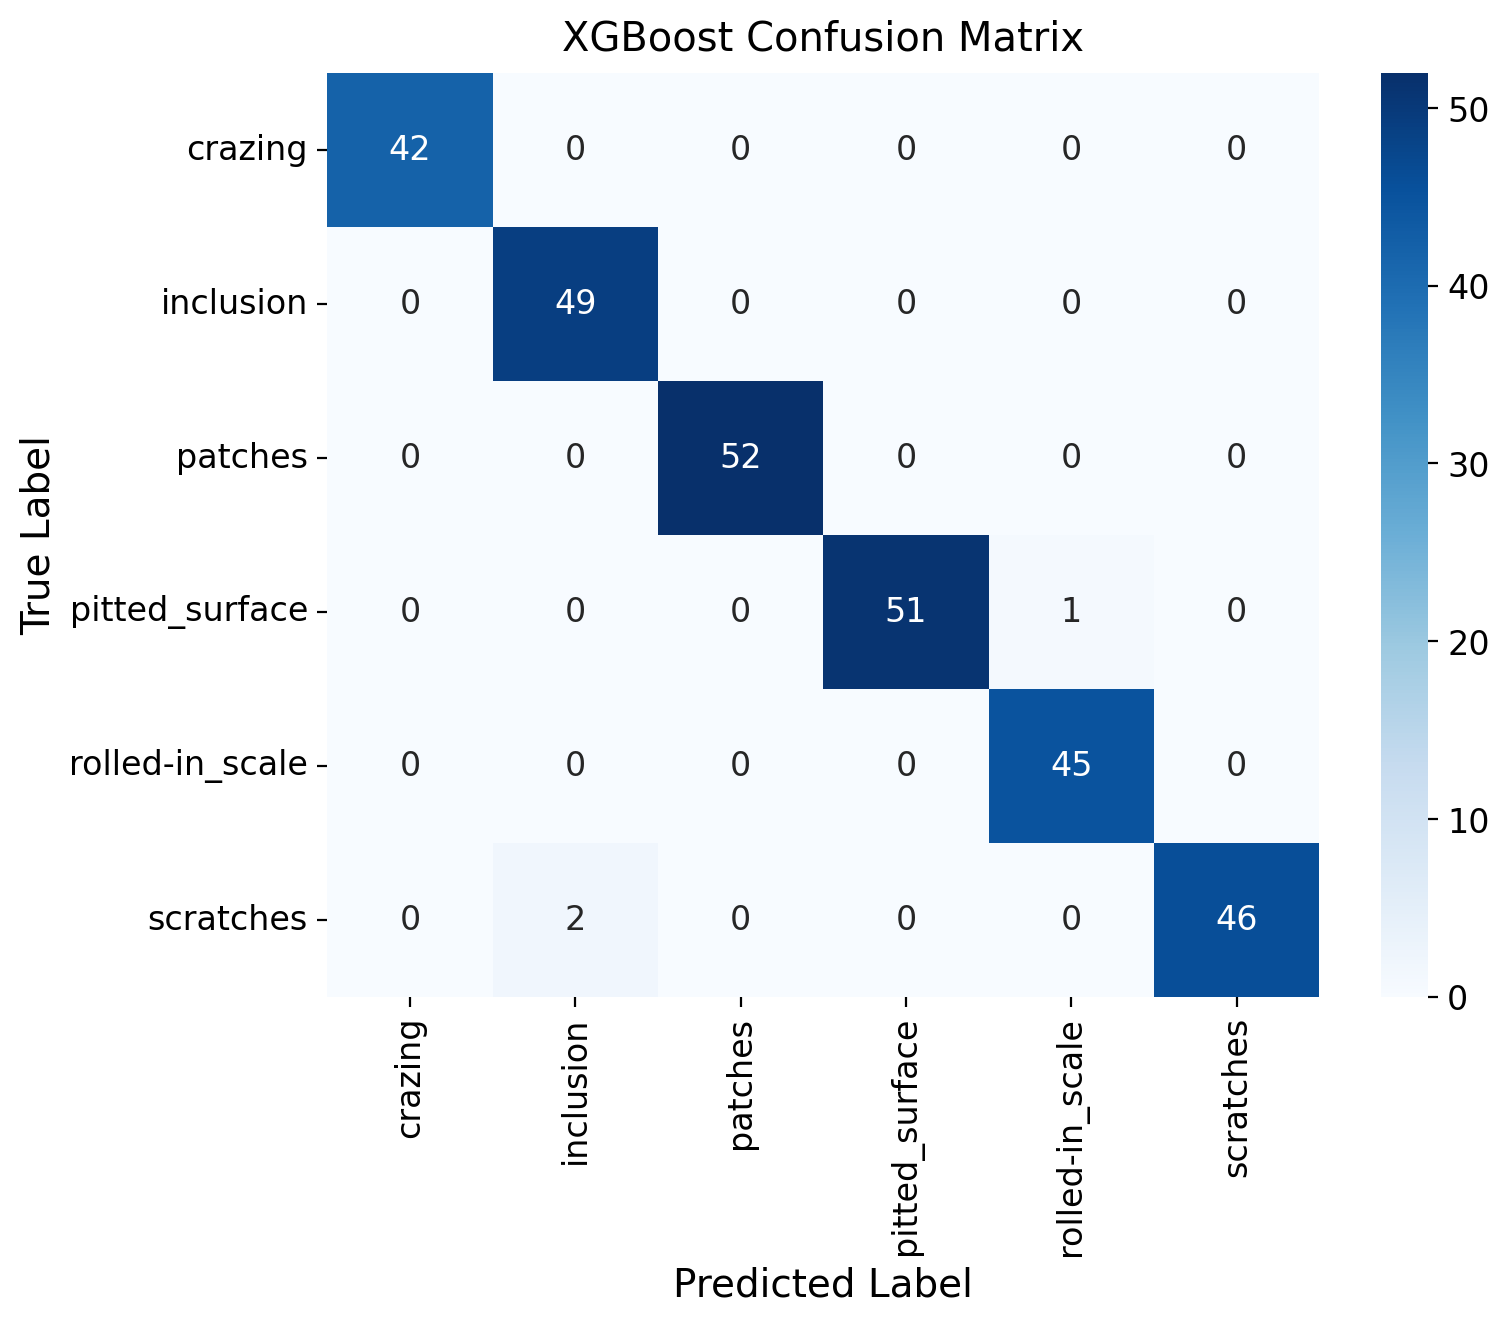


Mislabeled Images by Random Forest:


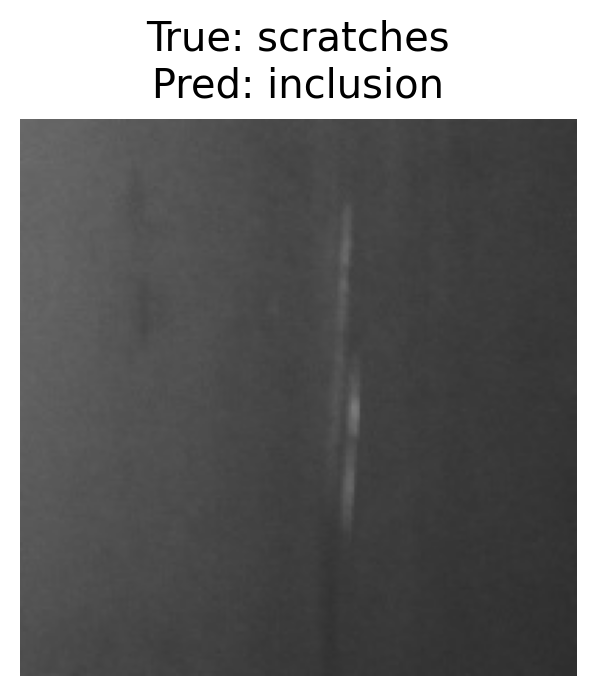


Mislabeled Images by XGBoost:


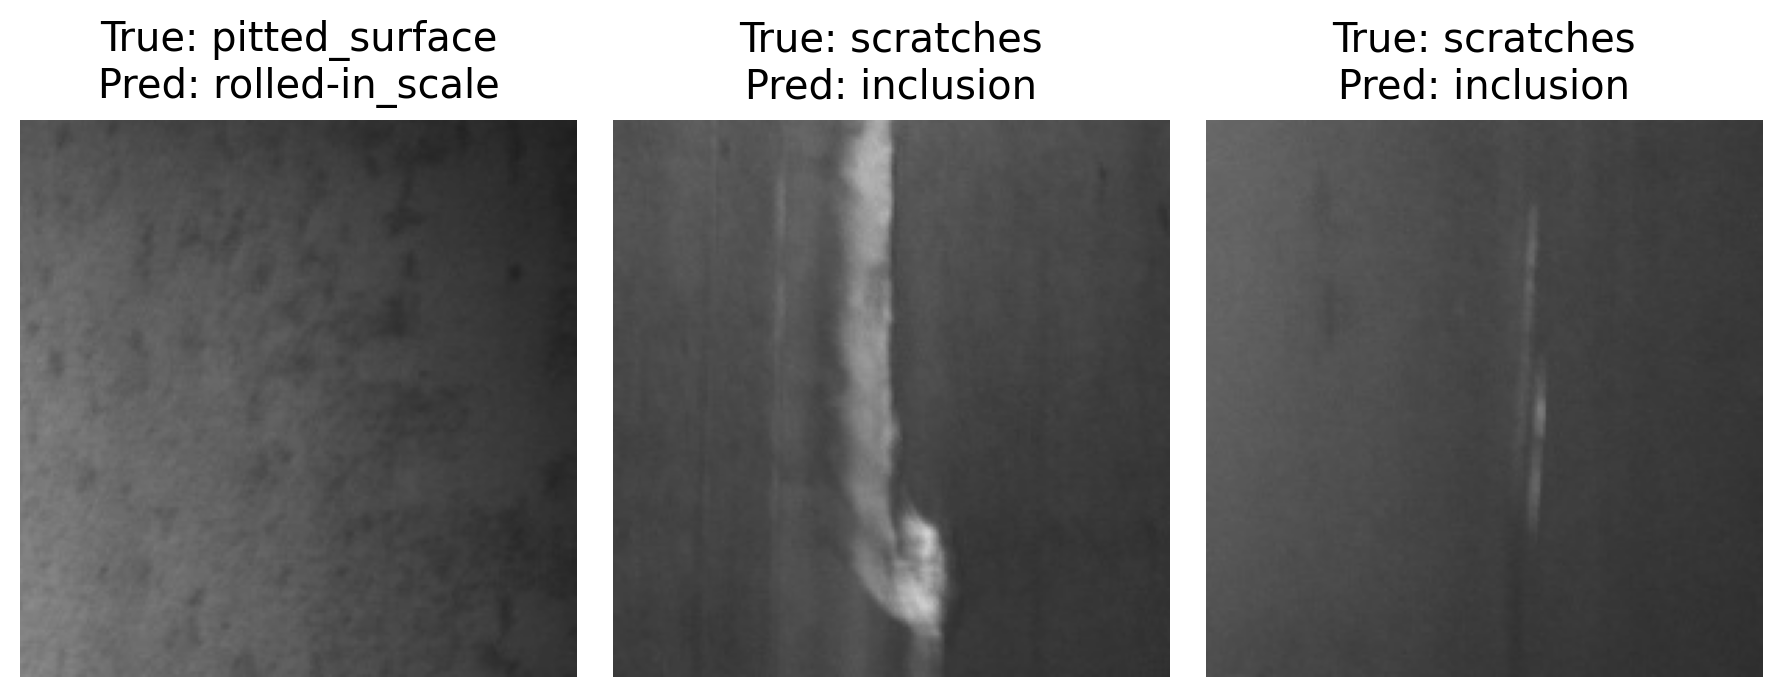

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Re-run train_test_split to get indices for the test set
indices = np.arange(len(all_embeddings))
X_train_idx, X_test_idx, _, _ = train_test_split(indices, labels, test_size=0.2, random_state=42)

# Get the image paths for the test set
img_paths_test = [img_paths[i] for i in X_test_idx]

# --- Confusion Matrix for Random Forest ---
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Confusion Matrix for XGBoost ---
plt.figure(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Display Mislabeled Images ---
def display_mislabeled_images(model_name, true_labels, predicted_labels, image_paths, label_encoder=None, max_images=10):
    print(f"\nMislabeled Images by {model_name}:")
    mislabeled_indices = np.where(true_labels != predicted_labels)[0]

    if len(mislabeled_indices) == 0:
        print(f"No mislabeled images found for {model_name}.")
        return

    count = 0
    plt.figure(figsize=(15, 5 * (max_images // 5 + 1)))
    for i, test_idx_in_split in enumerate(mislabeled_indices):
        if count >= max_images:
            break

        original_img_path = image_paths[test_idx_in_split]

        true_label = true_labels[test_idx_in_split]
        predicted_label = predicted_labels[test_idx_in_split]

        if label_encoder:
            true_label = label_encoder.inverse_transform([true_label])[0]
            predicted_label = label_encoder.inverse_transform([predicted_label])[0]

        try:
            img = Image.open(original_img_path)
            plt.subplot(max_images // 5 + 1, 5, count + 1)
            plt.imshow(img)
            plt.title(f"True: {true_label}\nPred: {predicted_label}")
            plt.axis('off')
            count += 1
        except Exception as e:
            print(f"Could not load image {original_img_path}: {e}")

    if count > 0: # Only show plot if images were displayed
        plt.tight_layout()
        plt.show()
    else: # If no images were loaded
        plt.close()

# For Random Forest
display_mislabeled_images('Random Forest', y_test, y_pred, img_paths_test, max_images=10)

# For XGBoost
display_mislabeled_images('XGBoost', y_test_encoded, y_pred_xgb, img_paths_test, label_encoder=le, max_images=10)


Both XGBoost and Random forest failed to categorize the same image of scratches as an inclusion, and XGBoost additionally failed to categorize two more images. The image which failed for both models exists right at the UMAP border of scratches and inclusions, and honestly has a bit of both scratches and inclusions (See screenshot below). Overall, the model managed to get most of the testing set correct which is extremely impressive for how little work I actually did.

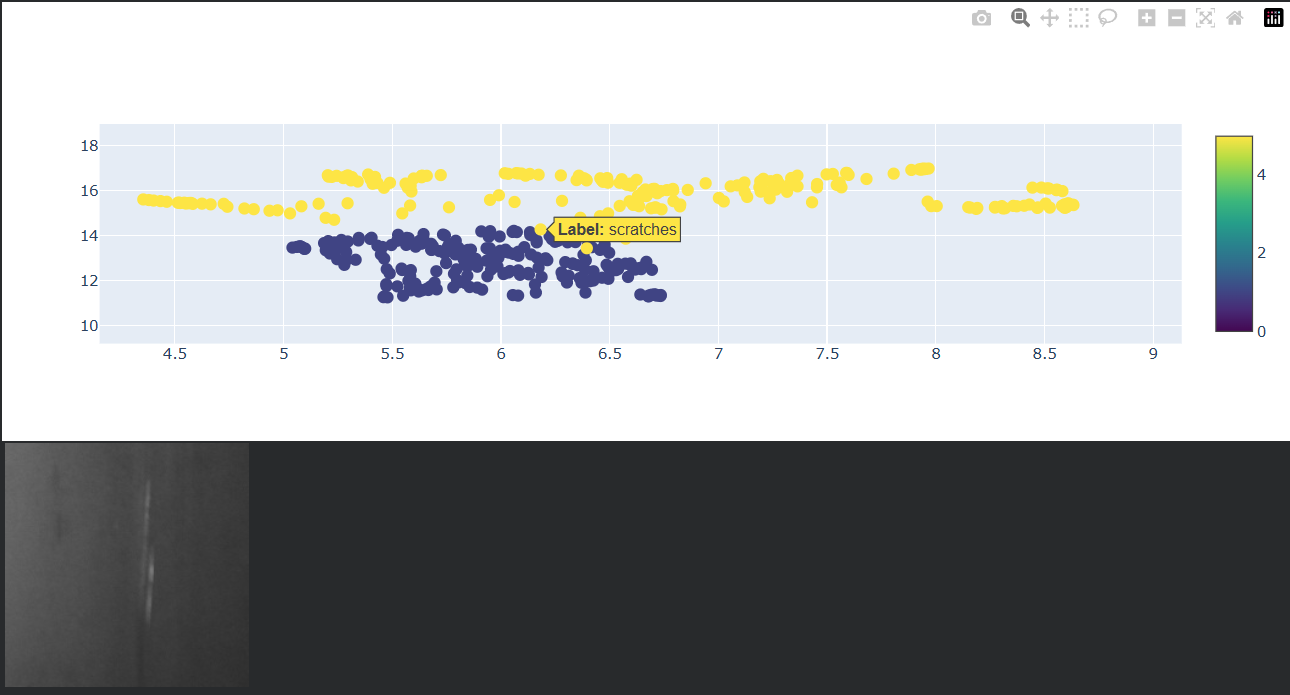